# Loading OCT Data from eyened_orm

This notebook demonstrates how to load 3D OCT volumes and layer segmentations from the `eyened_orm` database using the Retinalysis-OCT package.

## Overview

The `rtnls_oct.eyened.dataloading` module provides utilities to convert `ImageInstance` and `Segmentation` records from `eyened_orm` into `OCT3DVolume` and `PixelWiseSegmentation` objects that can be used with the Retinalysis-OCT analysis tools.


## 1. Setup

First, we need to import the necessary modules and set up the database connection. If your environment is already setup correctly, you can instantiate a database connection like this. Otherwise, see the documentation of EyeNED Platform for how to set this up

In [3]:
from eyened_orm import Database, ImageInstance, Modality, ETDRSField, ModelSegmentation, Feature, Scan, SegmentationModel
import random
import matplotlib.pyplot as plt


database = Database()


In [4]:
with database.get_session() as session:
    query = session.query(ImageInstance, ModelSegmentation).filter(ImageInstance.Modality == Modality.OCT).filter(ImageInstance.ETDRSField == ETDRSField.F2)\
        .join(Scan).filter(Scan.ScanMode == '3D-Scan')\
        .join(ModelSegmentation, ModelSegmentation.ImageInstanceID == ImageInstance.ImageInstanceID)\
        .join(SegmentationModel).join(Feature).where(Feature.FeatureName == 'Macular Layers NEW')

    random_instance = random.choice(query.all())
    instanceid = random_instance[0].ImageInstanceID
    segmentationid = random_instance[1].ModelSegmentationID
    


## 3. Loading OCT Volume

Load an OCT volume from an `ImageInstance` record using the `load_oct_volume_from_orm` function.


In [5]:
from rtnls_oct.eyened import dataloading

with database.get_session() as session:
    # Query the ImageInstance
    instance = session.query(ImageInstance)\
        .filter(ImageInstance.ImageInstanceID == instanceid).first()
    
    # Load OCT volume
    oct_volume = dataloading.load_oct_volume_from_orm(instance)
    
    # Display volume information
    print(f"OCT Volume Shape: {oct_volume.image.shape}")
    print(f"  - Number of B-scans: {oct_volume.n_bscans}")
    print(f"  - B-scan height: {oct_volume.image.shape[1]} pixels")
    print(f"  - B-scan width: {oct_volume.image.shape[2]} pixels")
    print(f"Laterality: {oct_volume.laterality}")
    print(f"Resolution: {oct_volume.res_depth_mm:.4f} x {oct_volume.res_height_mm:.4f} x {oct_volume.res_width_mm:.4f} mm")


OCT Volume Shape: (256, 992, 512)
  - Number of B-scans: 256
  - B-scan height: 992 pixels
  - B-scan width: 512 pixels
Laterality: R
Resolution: 0.0275 x 0.0026 x 0.0137 mm


## 4. Loading Segmentation with OCT Volume

Load both the segmentation and its associated OCT volume together using `load_model_segmentation_with_oct_by_id`. This is a convenient function that loads both in one call.


In [6]:
from rtnls_oct.eyened import dataloading

with database.get_session() as session:
    # Load both segmentation and OCT volume together
    segmentation, oct_volume = dataloading.load_model_segmentation_with_oct_by_id(
        segmentationid, 
        session
    )
    
    print(f"Segmentation data shape: {segmentation.data.shape}")
    print(f"Segmentation labels: {segmentation.labels}")


Segmentation data shape: (256, 992, 512)
Segmentation labels: {'background': 0, 'Retinal Nerve Fiber Layer (RNFL)': 1, 'Ganglion cell layer (GCL)': 2, 'Inner plexiform layer (IPL)': 3, 'Inner nuclear layer (INL)': 4, 'Outer plexiform layer (OPL)': 5, 'Outer nuclear layer (ONL)': 6, 'External limiting membrane (ELM)': 7, 'Myoid zone (MZ)': 8, 'Ellipsoid zone (EZ)': 9, 'Outer Segments (OS)': 10, 'Inter Digitation Zone (IDZ)': 11, 'Retinal pigment epithelium (RPE)': 12, 'Choroid': 13, 'Other': 14}


## 5. Working with Segmentation Data

The segmentation object is a `PixelWiseSegmentation` that contains pixel-wise labels for each layer. Let's explore the available layers and their properties.

In [7]:
# Check available labels
print("Available segmentation labels:")
for layer_name, label_value in segmentation.labels.items():
    print(f"  {layer_name}: {label_value}")

# Get information about the segmentation
print(f"\nSegmentation data type: {segmentation.data.dtype}")
print(f"Segmentation shape: {segmentation.data.shape}")
print(f"  - Number of B-scans: {segmentation.data.shape[0]}")
print(f"  - Height (depth): {segmentation.data.shape[1]} pixels")
print(f"  - Width: {segmentation.data.shape[2]} pixels")


Available segmentation labels:
  background: 0
  Retinal Nerve Fiber Layer (RNFL): 1
  Ganglion cell layer (GCL): 2
  Inner plexiform layer (IPL): 3
  Inner nuclear layer (INL): 4
  Outer plexiform layer (OPL): 5
  Outer nuclear layer (ONL): 6
  External limiting membrane (ELM): 7
  Myoid zone (MZ): 8
  Ellipsoid zone (EZ): 9
  Outer Segments (OS): 10
  Inter Digitation Zone (IDZ): 11
  Retinal pigment epithelium (RPE): 12
  Choroid: 13
  Other: 14

Segmentation data type: uint8
Segmentation shape: (256, 992, 512)
  - Number of B-scans: 256
  - Height (depth): 992 pixels
  - Width: 512 pixels


## 6. Visualizing the Data

Visualize the OCT volume and segmentation data.

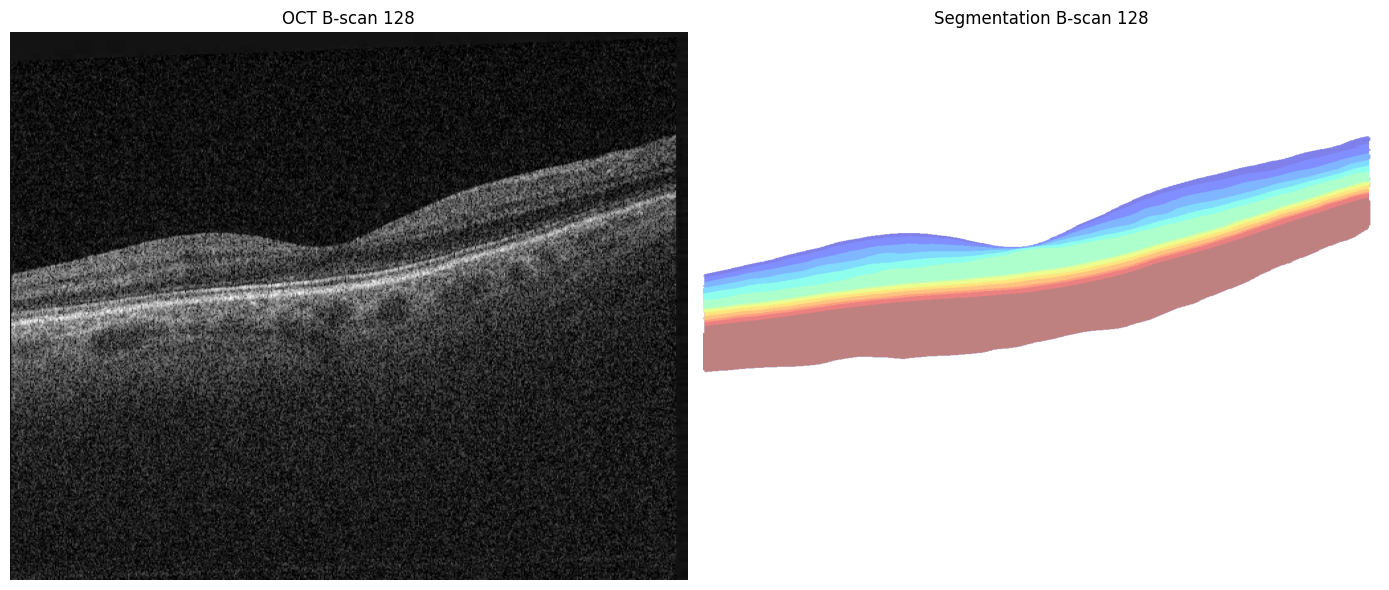

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Select a B-scan index (e.g., central B-scan)
bscan_index = oct_volume.n_bscans // 2

# Plot the OCT B-scan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot OCT B-scan
oct_volume.plot_bscan(bscan_index, ax=axes[0])
axes[0].set_title(f'OCT B-scan {bscan_index}')

# Plot segmentation for the same B-scan
segmentation.plot_bscan(bscan_index, ax=axes[1])
axes[1].set_title(f'Segmentation B-scan {bscan_index}')

plt.tight_layout()
plt.show()


## 7. Plotting Enface Image

Visualize the enface projection of the OCT volume.


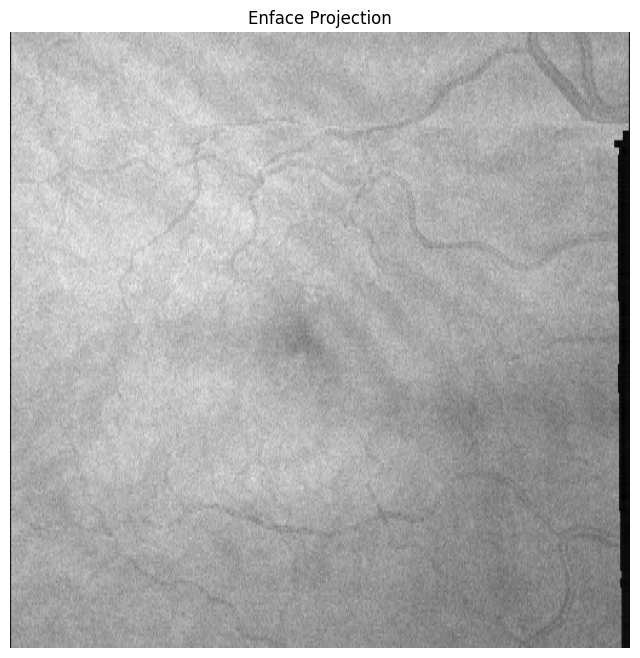

In [9]:
# Plot enface image
fig, ax = plt.subplots(figsize=(8, 8))
oct_volume.plot_enface_image(ax=ax)
ax.set_title('Enface Projection')
plt.show()


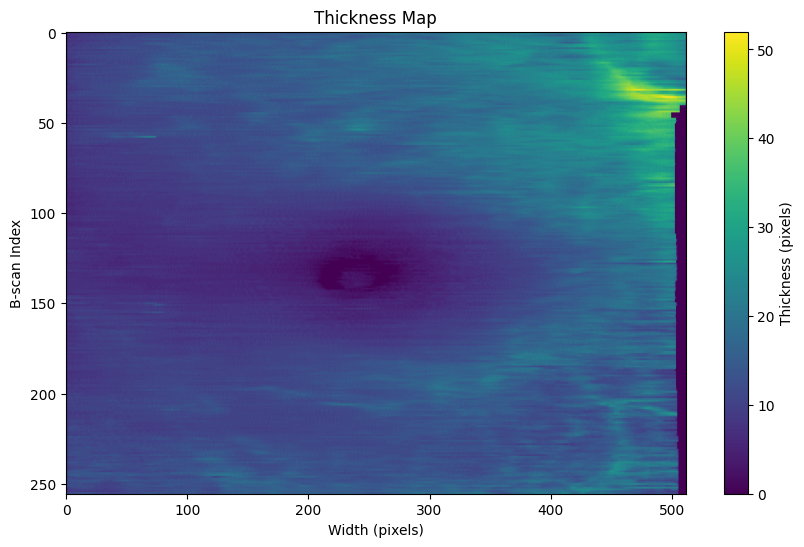

In [14]:
# Example: Extract a specific layer (if available in labels)
# Note: Layer names depend on the segmentation model used
labelname = 'Retinal Nerve Fiber Layer (RNFL)'
if labelname in segmentation.labels:
    label_value = segmentation.labels[labelname]
    layer_mask = (segmentation.data == label_value)
    
    # Get thickness map for this layer (sum along depth axis)
    thickness_map = np.sum(layer_mask, axis=1)
    
    # Visualize thickness map
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(thickness_map, cmap='viridis', aspect='auto')
    ax.set_title('Thickness Map')
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('B-scan Index')
    plt.colorbar(ax.images[0], ax=ax, label='Thickness (pixels)')
    plt.show()
else:
    print("RNFL layer not found in segmentation labels")
    print(f"Available layers: {list(segmentation.labels.keys())}")


## Summary

This notebook demonstrated:

1. **Setting up database connection** - Connecting to eyened_orm database
2. **Querying for OCT data** - Finding OCT images with segmentations
3. **Loading OCT volumes** - Converting ImageInstance to OCT3DVolume
4. **Loading segmentations** - Converting ModelSegmentation to PixelWiseSegmentation
5. **Visualizing data** - Plotting B-scans and enface images
6. **Working with layers** - Extracting and analyzing specific retinal layers

The loaded `OCT3DVolume` and `PixelWiseSegmentation` objects can now be used with other Retinalysis-OCT analysis tools such as:
- `RetinalThicknessReport` (after converting to ContoursData)
- ETDRS grid analysis
- Fovea localization
- Quality metrics
- PCA analysis

For more information, see the [eyened dataloading documentation](../eyened/README.md).
